In [40]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium as fm
from folium.plugins import HeatMap
import io
from PIL import Image
import selenium

In [2]:
# Import Datasets
listings_clean = pd.read_csv('../data/cleaned_airbnb_zillow_model_data.csv')
neighborhood = pd.read_csv('../data/neighborhood_zillow.csv')
listings_raw = pd.read_csv('../data/LA_listings.csv')

C:\Users\Hubert\AppData\Local\Temp\ipykernel_10160\1247378068.py:4: DtypeWarning: Columns (0: host_since) have mixed types. Specify dtype option on import or set low_memory=False.
  listings_raw = pd.read_csv('../data/LA_listings.csv')


## 1. Look into datasets

### Look over listings_clean dataset

In [3]:
listings_clean.shape

(35870, 10)

In [4]:
listings_clean.head()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,zillow_home_value_imputed,neighbourhood_cleansed,room_type,property_type,estimated_annual_revenue
0,81.0,30,45,0.33,361,8.973074e+05,Hollywood,Private room,Private room in rental unit,324.0
1,110.0,7,24,0.14,274,1.895851e+06,Santa Monica,Private room,Private room in rental unit,10010.0
2,88.0,30,37,0.19,291,8.973074e+05,Hollywood,Private room,Private room in rental unit,6512.0
3,1000.0,1,19,0.23,182,1.037584e+06,Bellflower,Private room,Private room in home,183000.0
4,81.0,30,238,1.21,311,1.412026e+06,Pico-Robertson,Private room,Private room in rental unit,4374.0


In [5]:
listings_clean.tail()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,zillow_home_value_imputed,neighbourhood_cleansed,room_type,property_type,estimated_annual_revenue
35865,181.0,1,0,0.0,363,1.037584e+06,East San Gabriel,Entire home/apt,Entire home,362.0
35866,141.0,3,0,0.0,365,1.037584e+06,East San Gabriel,Private room,Private room in home,0.0
35867,81.0,1,0,0.0,254,1.452904e+06,Toluca Lake,Private room,Private room in home,8991.0
35868,92.0,30,0,0.0,365,9.859590e+05,Westwood,Private room,Private room in rental unit,0.0
35869,91.0,30,0,0.0,365,1.205103e+06,Woodland Hills,Entire home/apt,Entire home,0.0


In [6]:
listings_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 35870 entries, 0 to 35869
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      35870 non-null  float64
 1   minimum_nights             35870 non-null  int64  
 2   number_of_reviews          35870 non-null  int64  
 3   reviews_per_month          35870 non-null  float64
 4   availability_365           35870 non-null  int64  
 5   zillow_home_value_imputed  35870 non-null  float64
 6   neighbourhood_cleansed     35870 non-null  str    
 7   room_type                  35870 non-null  str    
 8   property_type              35870 non-null  str    
 9   estimated_annual_revenue   35870 non-null  float64
dtypes: float64(4), int64(3), str(3)
memory usage: 2.7 MB


In [7]:
listings_clean.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,zillow_home_value_imputed,estimated_annual_revenue
count,35870.000000,35870.000000,35870.000000,35870.000000,35870.000000,3.587000e+04,35870.000000
mean,232.136521,16.947421,43.221968,1.176960,254.677614,1.263846e+06,23046.026234
std,267.026348,20.742451,91.345400,1.712029,108.742233,8.523269e+05,35166.306194
min,31.000000,1.000000,0.000000,0.000000,0.000000,2.878604e+05,0.000000
25%,95.000000,2.000000,1.000000,0.010000,173.000000,8.671920e+05,1224.000000
50%,155.000000,7.000000,7.000000,0.410000,274.000000,1.037584e+06,10415.000000
75%,253.000000,30.000000,43.000000,1.830000,357.000000,1.362275e+06,29430.000000
max,2557.000000,365.000000,3151.000000,66.590000,365.000000,5.909378e+06,279760.000000


### Look over neighborhood dataset

In [8]:
neighborhood.shape

(21600, 326)

In [9]:
neighborhood.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,112345,0,Maryvale,neighborhood,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,70265.246748,...,3.348063e+05,3.334858e+05,3.323610e+05,3.319901e+05,3.322638e+05,3.325127e+05,3.327364e+05,3.325103e+05,3.319002e+05,3.306516e+05
1,192689,1,Paradise,neighborhood,NV,NV,Las Vegas,"Las Vegas-Henderson-Paradise, NV",Clark County,136526.801960,...,4.010091e+05,3.995406e+05,3.983678e+05,3.977305e+05,3.972949e+05,3.969128e+05,3.965360e+05,3.960044e+05,3.954638e+05,3.943812e+05
2,270958,2,Upper West Side,neighborhood,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,409392.009209,...,1.316164e+06,1.314903e+06,1.318541e+06,1.324716e+06,1.329700e+06,1.337544e+06,1.347921e+06,1.355638e+06,1.357036e+06,1.353330e+06
3,270957,3,Upper East Side,neighborhood,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,666524.848137,...,1.272871e+06,1.278652e+06,1.287203e+06,1.294640e+06,1.298567e+06,1.307315e+06,1.323102e+06,1.337632e+06,1.343938e+06,1.339842e+06
4,118208,4,South Los Angeles,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,134453.790051,...,6.770960e+05,6.801553e+05,6.823887e+05,6.835706e+05,6.853429e+05,6.855409e+05,6.846294e+05,6.807705e+05,6.759697e+05,6.725631e+05


In [10]:
neighborhood.tail()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
21595,416161,28019,Beacon Square,neighborhood,TN,TN,Nashville,"Nashville-Davidson--Murfreesboro--Franklin, TN",Davidson County,NaN,...,474108.043499,471913.710562,469237.364707,466484.561112,463485.488178,461549.255878,459209.039330,457710.675637,456175.533886,456305.536048
21596,829241,28019,Owens Oak,neighborhood,TX,TX,Hurst,"Dallas-Fort Worth-Arlington, TX",Tarrant County,NaN,...,356107.041112,356463.615405,357923.146132,360001.398224,361854.415283,361580.748579,360826.671672,359947.872036,360056.894803,360801.356801
21597,786428,28019,Village Green,neighborhood,SC,SC,Charleston,"Charleston-North Charleston, SC",Charleston County,145974.787649,...,479124.925983,479508.482559,480743.207809,482021.923007,483082.265902,483655.165638,483793.892773,484207.701863,485314.053616,486257.179112
21598,813833,28019,Huntington Place,neighborhood,VA,VA,Henrico,"Richmond, VA",Henrico County,NaN,...,382251.377081,382495.772936,382706.436192,382545.533231,382501.423878,382494.317757,382908.270315,383313.956828,383743.253177,383888.363181
21599,831177,28019,Sanctuary,neighborhood,FL,FL,Riverview,"Tampa-St. Petersburg-Clearwater, FL",Hillsborough County,NaN,...,351803.739434,350410.858613,349639.128708,348922.773428,348424.851413,348096.285075,348828.267731,349499.400857,349580.427857,349047.263695


In [11]:
neighborhood.info()

<class 'pandas.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Columns: 326 entries, RegionID to 2026-05-31
dtypes: float64(317), int64(2), str(7)
memory usage: 53.7 MB


In [12]:
neighborhood.describe()

,RegionID,SizeRank,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31,2000-08-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
count,21600.000000,21600.000000,1.115700e+04,1.123500e+04,1.124600e+04,1.125500e+04,1.131900e+04,1.133100e+04,1.134000e+04,1.136400e+04,...,2.159800e+04,2.160000e+04,2.159900e+04,2.159800e+04,2.159800e+04,2.159900e+04,2.160000e+04,2.160000e+04,2.160000e+04,2.160000e+04
mean,501005.826528,12420.533287,1.661156e+05,1.662577e+05,1.668320e+05,1.681827e+05,1.698383e+05,1.714586e+05,1.731539e+05,1.747429e+05,...,5.139368e+05,5.141074e+05,5.149866e+05,5.165451e+05,5.182671e+05,5.197031e+05,5.207644e+05,5.212081e+05,5.208935e+05,5.203904e+05
std,277555.742295,7632.459659,1.378440e+05,1.382774e+05,1.391497e+05,1.411531e+05,1.434021e+05,1.458387e+05,1.483984e+05,1.508915e+05,...,5.226641e+05,5.251667e+05,5.291872e+05,5.347277e+05,5.399289e+05,5.439436e+05,5.464403e+05,5.478248e+05,5.479933e+05,5.485051e+05
min,3324.000000,0.000000,4.181846e+03,4.148911e+03,4.144830e+03,4.144680e+03,4.178620e+03,4.244943e+03,4.266033e+03,4.294245e+03,...,2.515276e+04,2.455738e+04,2.418083e+04,2.403427e+04,2.399138e+04,2.417128e+04,2.419878e+04,2.441790e+04,2.465964e+04,2.509140e+04
25%,270162.750000,5673.000000,8.648145e+04,8.643046e+04,8.653291e+04,8.687292e+04,8.755302e+04,8.798928e+04,8.836544e+04,8.891456e+04,...,2.575449e+05,2.572713e+05,2.570432e+05,2.570122e+05,2.571356e+05,2.574801e+05,2.581371e+05,2.586310e+05,2.584912e+05,2.580500e+05
50%,416471.500000,12060.000000,1.302345e+05,1.302055e+05,1.303759e+05,1.310717e+05,1.323900e+05,1.333006e+05,1.340717e+05,1.346870e+05,...,3.909707e+05,3.905206e+05,3.902681e+05,3.904125e+05,3.907752e+05,3.916436e+05,3.918591e+05,3.919362e+05,3.916634e+05,3.908386e+05
75%,806956.250000,18922.000000,1.942741e+05,1.946261e+05,1.953206e+05,1.965840e+05,1.982870e+05,1.998489e+05,2.017738e+05,2.032172e+05,...,5.935718e+05,5.934047e+05,5.937704e+05,5.946614e+05,5.963621e+05,5.968178e+05,5.969043e+05,5.965985e+05,5.955024e+05,5.945905e+05
max,832002.000000,28019.000000,2.841909e+06,2.867486e+06,2.898675e+06,2.940530e+06,2.986749e+06,3.020285e+06,3.079186e+06,3.140429e+06,...,2.050483e+07,2.078276e+07,2.109775e+07,2.141741e+07,2.158601e+07,2.170875e+07,2.178128e+07,2.181882e+07,2.179202e+07,2.178952e+07


### Look over listings_raw dataset

In [13]:
listings_raw.shape

(45533, 26)

In [14]:
listings_raw.head()

,Unnamed: 0,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
0,0,670339032744709144,Westwood lovely three bedrooms three bathrooms,4780152,Moon,20/01/13,within a few hours,0.96,f,West Los Angeles,...,3.0,3.0,3.0,399.0,30,365,0,NaN,NaN,f
1,1,37014494,Spanish style lower duplex near Beverly Hills,278288178,Ida,22/07/19,NaN,NaN,f,Beverlywood,...,NaN,2.0,NaN,NaN,30,0,0,NaN,NaN,f
2,2,1024835174766068422,Charming Beverly Hills Home,513813179,Tiana,08/05/23,within a day,0.60,f,Beverly Hills,...,3.0,3.0,3.0,434.0,30,267,0,NaN,NaN,f
3,3,850744632375448560,Tianpu's warm room with bathroom,432956623,Dan,22/11/21,a few days or more,0.20,f,Temple City,...,1.0,1.0,1.0,49.0,1,364,1,3.00,NaN,f
4,4,953950676345326970,"Santa Monica apt, free parking, steps to the b...",528669205,Farkhat,29/07/23,within an hour,1.00,t,Santa Monica,...,1.0,0.0,1.0,231.0,5,193,44,4.93,Exempt,t


In [15]:
listings_raw.tail()

,Unnamed: 0,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
45528,45528,892894292387453414,"Cozy 1 Bed, 2 Bath apartment",111223499,Eric,42748.0,NaN,NaN,f,Marina del Rey,...,NaN,1.0,NaN,NaN,1,0,0,NaN,NaN,f
45529,45529,944430003646575559,DTLA Loft | Industrial | Central,528133129,Michael,45133.0,NaN,NaN,f,Downtown,...,NaN,NaN,NaN,NaN,30,89,0,NaN,NaN,f
45530,45530,746345243817423719,"Long Beach, Rustic Suite 3 Beds, 1 Bath, 2 Rooms",484471086,Cabana,44855.0,within an hour,1.00,f,Long Beach,...,NaN,2.0,NaN,NaN,31,244,0,NaN,Exempt,t
45531,45531,32943553,Charming Craftsman Bungalow w/ Outdoor Sauna,8110883,Christine,41498.0,within an hour,1.00,t,Jefferson Park,...,1.0,0.0,1.0,116.0,2,141,212,4.84,HSR19-000881,t
45532,45532,37853838,"Views, big backyard, central LA!",8401300,Maite,41511.0,a few days or more,0.11,f,View Park-Windsor Hills,...,2.5,3.0,4.0,338.0,1,361,12,4.83,NaN,f


In [16]:
listings_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 45533 entries, 0 to 45532
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    45533 non-null  int64  
 1   id                            45533 non-null  int64  
 2   name                          45532 non-null  str    
 3   host_id                       45533 non-null  int64  
 4   host_name                     45531 non-null  str    
 5   host_since                    45531 non-null  object 
 6   host_response_time            35445 non-null  str    
 7   host_response_rate            35445 non-null  float64
 8   host_is_superhost             44281 non-null  str    
 9   neighbourhood_cleansed        45533 non-null  str    
 10  neighbourhood_group_cleansed  45533 non-null  str    
 11  latitude                      45533 non-null  float64
 12  longitude                     45533 non-null  float64
 13  property_typ

In [17]:
listings_raw.describe()

,Unnamed: 0,id,host_id,host_response_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating
count,45533.00000,4.553300e+04,4.553300e+04,35445.000000,45533.000000,45533.000000,45533.000000,37294.000000,42494.000000,37199.000000,37296.000000,45533.000000,45533.000000,45533.000000,33387.000000
mean,22766.00000,5.208941e+17,1.950473e+08,0.952010,34.055308,-118.312743,4.019876,1.649434,1.786817,2.255786,289.377762,17.858520,195.093449,36.658929,4.778747
std,13144.38924,4.976570e+17,1.899825e+08,0.168667,0.141394,0.172210,2.861610,1.218398,1.339151,1.811313,715.366985,28.836101,133.394403,80.548528,0.415048
min,0.00000,1.090000e+02,5.210000e+02,0.000000,33.338360,-118.917134,1.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,11383.00000,3.319485e+07,2.632699e+07,1.000000,33.998590,-118.413090,2.000000,1.000000,1.000000,1.000000,98.000000,2.000000,75.000000,0.000000,4.730000
50%,22766.00000,6.363561e+17,1.165631e+08,1.000000,34.060625,-118.343391,3.000000,1.000000,1.000000,2.000000,155.000000,14.000000,202.000000,6.000000,4.900000
75%,34149.00000,1.006571e+18,3.712316e+08,1.000000,34.108160,-118.233737,6.000000,2.000000,2.000000,3.000000,260.000000,30.000000,335.000000,34.000000,5.000000
max,45532.00000,1.238217e+18,5.997497e+08,1.000000,34.811183,-117.653352,16.000000,50.000000,50.000000,50.000000,56425.000000,1124.000000,365.000000,3024.000000,5.000000


## 2. Plot LA population change over time for summary of neighborhoods

In [18]:
# Find list of neighborhood in LA dataset
LA_neighborhoods = listings_clean['neighbourhood_cleansed'].unique()

# Filter neighborhood dataset for neighborhoods in LA
LA_pop = neighborhood.loc[neighborhood['City'] == 'Los Angeles']
LA_pop = LA_pop.set_index(np.arange(len(LA_pop))) # rescale index

In [19]:
# Drop regions not in LA neighborhoods
drop_list = []
for i in range(len(LA_pop)):
    if (LA_pop['RegionName'].unique()[i] not in LA_neighborhoods):
        drop_list.append(i)

LA_pop = LA_pop.drop(drop_list)


In [20]:
# Check if LA_pop has changed- first two rows should be dropped
LA_pop.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
2,32059,21,Hollywood,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,233700.343427,...,914682.310316,911623.919964,911859.564379,913823.509133,915699.146962,915700.266094,913013.596663,907783.932677,901593.022660,897307.428451
3,46795,41,North Hollywood,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,165904.797007,...,858925.839175,862125.649390,866839.585272,871676.161922,876487.085545,878058.925017,877128.449223,872869.152619,867861.925274,863554.117012
4,41466,60,Van Nuys,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,134366.381846,...,800088.758883,803757.411794,807299.345627,811314.196805,815627.107578,817694.081261,817572.182589,814454.036825,809838.925406,806159.851458
6,34213,65,Sylmar,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,164209.293327,...,780475.174021,783305.054881,786967.577862,790680.914257,794438.266009,795717.345087,795177.407966,792953.585744,790674.342025,787959.496057
7,54300,67,San Pedro,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,261904.324773,...,849316.445326,850665.798206,852175.272524,854540.914468,857057.051428,858773.955901,857453.014963,854061.126222,850462.206031,848804.194483


In [21]:
## Note data was collected on Sept 4, 2024 so keep track until end of August 2024
# Remove columns later than August 31, 2024
LA_pop = LA_pop.iloc[:, :306]

# Sort values by population at end of August 2024
LA_pop = LA_pop.sort_values(by = ['2024-09-30'], ascending = False)

LA_pop.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2023-12-31,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30
66,19810,614,Pacific Palisades,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,822692.243875,...,3.642114e+06,3.632336e+06,3.599405e+06,3.552426e+06,3.521928e+06,3.493371e+06,3.454467e+06,3.429996e+06,3.416191e+06,3.420674e+06
79,113749,1670,Beverly Crest,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,626986.296403,...,3.004395e+06,2.984190e+06,2.943320e+06,2.901927e+06,2.873710e+06,2.854254e+06,2.826365e+06,2.812203e+06,2.809062e+06,2.825301e+06
45,113910,375,Brentwood,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,560455.754104,...,2.837763e+06,2.831390e+06,2.805294e+06,2.777526e+06,2.759830e+06,2.751725e+06,2.734045e+06,2.732908e+06,2.739259e+06,2.757265e+06
76,403142,1359,Cheviot Hills,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,547439.566562,...,2.604282e+06,2.590859e+06,2.558716e+06,2.524208e+06,2.499239e+06,2.490315e+06,2.475380e+06,2.474315e+06,2.478352e+06,2.496885e+06
86,403183,2848,Beverlywood,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,504809.243186,...,2.323645e+06,2.312270e+06,2.288114e+06,2.262305e+06,2.241461e+06,2.227680e+06,2.212285e+06,2.213737e+06,2.224308e+06,2.242962e+06


In [22]:
# Remove extra columns
extra_col = ['RegionID', 'SizeRank', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']
LA_pop = LA_pop.drop(extra_col, axis = 1)

# Change index to neighborhood names
LA_pop = LA_pop.set_index('RegionName')

# Remove rows in NA population
LA_pop = LA_pop.dropna()

# Set populations as integers
LA_pop = LA_pop.astype('int32')

# Check resulting dataframe
LA_pop.head()

,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-30,2000-10-31,...,2023-12-31,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30
RegionName,,,,,,,,,,,,,,,,,,,,,
Pacific Palisades,822692,822277,825408,830534,836074,840580,845647,853078,860592,866518,...,3642113,3632336,3599404,3552426,3521928,3493371,3454467,3429996,3416191,3420673
Beverly Crest,626986,628364,631081,637223,644729,651842,659810,668527,677679,684876,...,3004395,2984189,2943320,2901927,2873710,2854254,2826365,2812203,2809062,2825300
Brentwood,560455,559819,562546,567717,574935,581301,587750,594491,600825,605323,...,2837762,2831390,2805293,2777525,2759830,2751724,2734044,2732908,2739259,2757264
Cheviot Hills,547439,547126,548939,552725,559148,566442,574247,581742,586775,588999,...,2604281,2590858,2558716,2524207,2499239,2490315,2475380,2474315,2478352,2496884
Beverlywood,504809,504211,505621,508846,514134,520469,526928,532524,536281,538303,...,2323645,2312269,2288114,2262304,2241460,2227680,2212285,2213737,2224307,2242961


In [23]:
# Tranpose dataframe to have neighborhoods as columns and dates as rows
LA_pop = LA_pop.transpose()

# Add mean population for each year
LA_pop.insert(0, '75% Quantile', np.quantile(LA_pop, 0.75, axis = 1))
LA_pop.insert(0, 'Median', np.median(LA_pop, axis = 1))
LA_pop.insert(0, '25% Quantile', np.quantile(LA_pop, 0.25, axis = 1))

# Check formatting of LA_pop
LA_pop.head()

RegionName,25% Quantile,Median,75% Quantile,Pacific Palisades,Beverly Crest,Brentwood,Cheviot Hills,Beverlywood,Hollywood Hills,Los Feliz,...,Arleta,Canoga Park,Lincoln Heights,Pico-Union,Wilmington,Pacoima,Panorama City,Boyle Heights,Downtown,Watts
2000-01-31,158943.0,206859.0,297842.0,822692,626986,560455,547439,504809,390873,346996,...,151418,142494,131991,115760,158093,119180,112884,136794,172491,105865
2000-02-29,159415.0,207297.5,298571.5,822277,628364,559819,547126,504211,391161,347669,...,151638,142732,132251,116688,158626,119369,113108,137074,173411,105872
2000-03-31,160218.0,208374.5,300077.0,825408,631081,562546,548939,505621,393355,349241,...,152281,143442,132898,117547,159419,119933,113734,137405,175064,106210
2000-04-30,161861.0,210675.0,303073.0,830534,637223,567717,552725,508846,397021,353191,...,153519,144795,134437,119343,160997,121067,115023,138059,178438,107008
2000-05-31,163893.0,214095.5,306641.0,836074,644729,574935,559148,514134,401048,357187,...,155142,146471,136128,121417,162504,122560,116734,139010,182321,107792


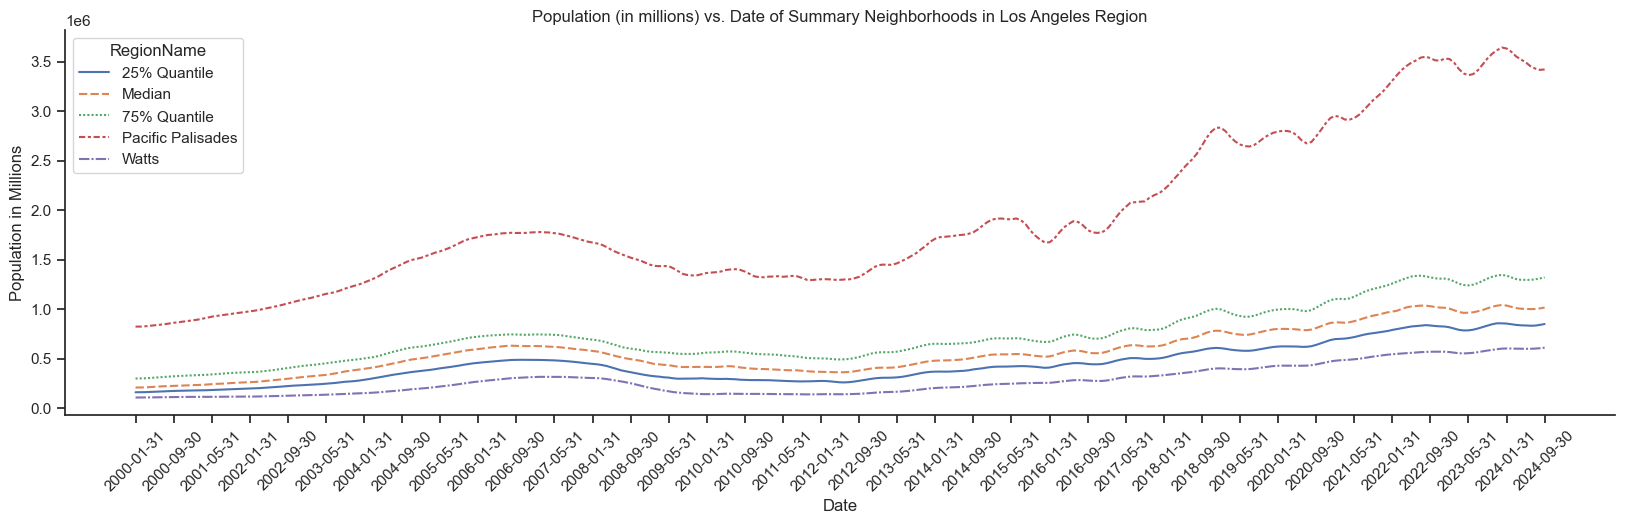

In [41]:
## Plot min, max, 25% quantile, 75% quantile, and 50% quantile for neighborhoods
## Sometimes have to run cell again
# Store summary neighborhoods
LA_pop_summ = LA_pop.iloc[:, [0, 1, 2, 3, -1]]

# Create time-series plot of populations
plot = sns.lineplot(data = LA_pop_summ)

# Set theme
sns.set_theme(rc = {'figure.figsize':(20, 5)})
sns.set_style('ticks')
sns.despine()

# Add labels and adjust axes
plot.set_xlabel(xlabel = 'Date')
plot.set_ylabel(ylabel = 'Population in Millions')
plot.set_title('Population (in millions) vs. Date of Summary Neighborhoods in Los Angeles Region')
plot.set_xticks(range(0, 300, 8))
plt.tick_params("x", rotation=45)

# Save figure
plt.savefig('./LA_pop_summary.png')

plt.show()

## 3. Plot distributions of numeric predictor variables

In [25]:
# Remove categorical and outcome variables
listings_clean_num = listings_clean.drop(['neighbourhood_cleansed', 'room_type', 'property_type', 'price'], axis = 1)

# Check resulting dataframe
listings_clean_num.head()

,minimum_nights,number_of_reviews,reviews_per_month,availability_365,zillow_home_value_imputed,estimated_annual_revenue
0,30,45,0.33,361,8.973074e+05,324.0
1,7,24,0.14,274,1.895851e+06,10010.0
2,30,37,0.19,291,8.973074e+05,6512.0
3,1,19,0.23,182,1.037584e+06,183000.0
4,30,238,1.21,311,1.412026e+06,4374.0


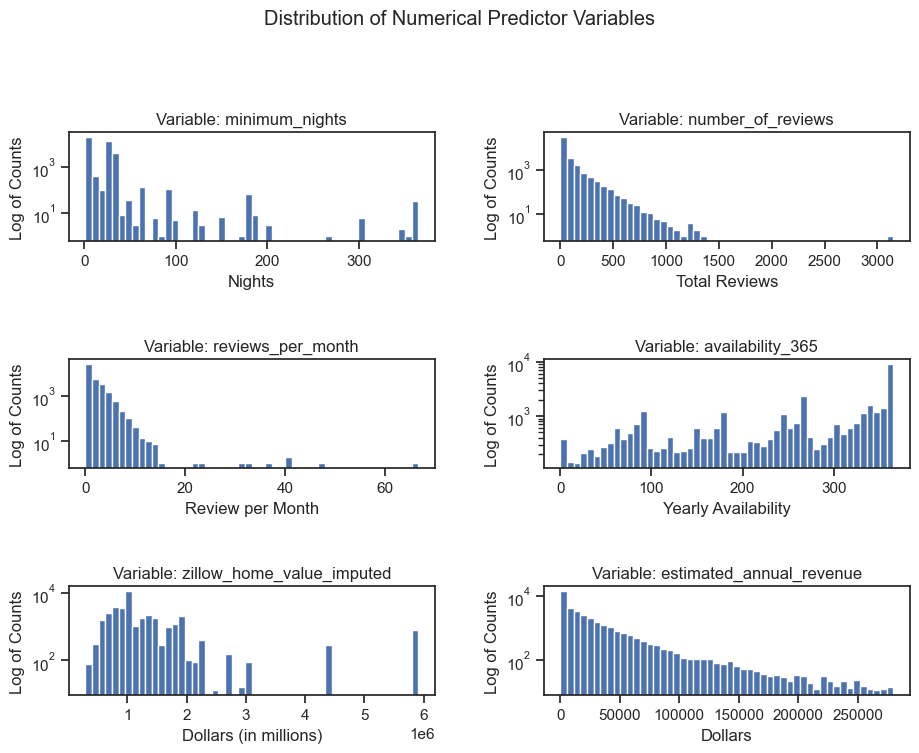

In [26]:
## Create histograms for each numerical predictor variable
fig, axs = plt.subplots(3, 2, figsize=(10, 8))

# Plot a histogram for each variable with log frequnecy
for ax, col in zip(axs.flatten(), list(listings_clean_num.columns)):
    listings_clean_num.hist(column = col, ax = ax, bins = 50, log = True)
    ax.set_title(f'Variable: {col}')
    ax.grid(False)
    ax.set_ylabel('Log of Counts')

# Add labels for x-axes
axs[0, 0].set_xlabel('Nights')
axs[0, 1].set_xlabel('Total Reviews')
axs[1, 0].set_xlabel('Review per Month')
axs[1, 1].set_xlabel('Yearly Availability')
axs[2, 0].set_xlabel('Dollars (in millions)')
axs[2, 1].set_xlabel('Dollars')

# Add title and padding
plt.suptitle('Distribution of Numerical Predictor Variables')
fig.tight_layout(pad = 3)

# Save
plt.savefig('./numeric_dist.png')

plt.show()

## 4. Map locations of Airbnbs in Los Angeles

#### Copy over preprocessing steps from Kala's notebook

In [27]:
listings_raw.shape

(45533, 26)

In [28]:
## Clean Airbnb price column

# Convert price to numeric
listings_raw["price"] = (
    listings_raw["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
listings_raw['price'] = pd.to_numeric(listings_raw['price'], errors="coerce")

# Drop rows missing price because price is needed for target
listings_raw = listings_raw.dropna(subset=["price"])

# Remove zero or negative prices
listings_raw = listings_raw[listings_raw["price"] > 0]

print("After price cleaning:", listings_raw.shape)

After price cleaning: (37296, 26)


In [29]:
#Cleaning rest of columns
numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "bedrooms",
    "bathrooms"
]

for col in numeric_cols:
    listings_raw[col] = pd.to_numeric(listings_raw[col], errors="coerce")

print("After numeric cleaning:", listings_raw.shape)

After numeric cleaning: (37296, 26)


In [30]:
#Create estimated annual revenue
listings_raw["estimated_booked_nights"] = 365 - listings_raw["availability_365"]

listings_raw = listings_raw[
    (listings_raw["estimated_booked_nights"] >= 0) &
    (listings_raw["estimated_booked_nights"] <= 365)
]

listings_raw["estimated_annual_revenue"] = (
    listings_raw["price"] * listings_raw["estimated_booked_nights"]
)

print("After target creation:", listings_raw.shape)

listings_raw[["price", "availability_365", "estimated_booked_nights", "estimated_annual_revenue"]].head()

After target creation: (37296, 28)


,price,availability_365,estimated_booked_nights,estimated_annual_revenue
0,399.0,365,0,0.0
2,434.0,267,98,42532.0
3,49.0,364,1,49.0
4,231.0,193,172,39732.0
5,62.0,278,87,5394.0


In [31]:
before_outliers = listings_raw.shape[0]

price_low, price_high = listings_raw["price"].quantile([0.01, 0.99])
revenue_low, revenue_high = listings_raw["estimated_annual_revenue"].quantile([0.01, 0.99])

listings_raw = listings_raw[
    (listings_raw["price"] >= price_low) &
    (listings_raw["price"] <= price_high) &
    (listings_raw["estimated_annual_revenue"] >= revenue_low) &
    (listings_raw["estimated_annual_revenue"] <= revenue_high) &
    (listings_raw["minimum_nights"] <= 365)
]

print("Rows before outlier filtering:", before_outliers)
print("Rows after outlier filtering:", listings_raw.shape[0])
print("Rows removed:", before_outliers - listings_raw.shape[0])

Rows before outlier filtering: 37296
Rows after outlier filtering: 36371
Rows removed: 925


#### Create dataframe of locations by neighborhood

In [32]:
# Check columns in dataframe
listings_raw.columns

Index(['Unnamed: 0', 'id', 'name', 'host_id', 'host_name', 'host_since',
       'host_response_time', 'host_response_rate', 'host_is_superhost',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'license',
       'instant_bookable', 'estimated_booked_nights',
       'estimated_annual_revenue'],
      dtype='str')

In [34]:
# Create dataframe with needed columns
loc_cols = ['id', 'neighbourhood_cleansed', 'latitude', 'longitude', 'price', 'estimated_annual_revenue']
listings_loc = listings_raw[loc_cols]

# Group data in dataframe by neighborhood and take mean
listings_loc = listings_loc.groupby(['neighbourhood_cleansed']).mean()

# Add number of listings in neighborhood as a column and stratify by color
count = pd.DataFrame(listings_raw['neighbourhood_cleansed'].value_counts())
listings_loc = listings_loc.join(count, on = 'neighbourhood_cleansed')
listings_loc['count_color'] = listings_loc['count'].apply(lambda count: '#00008B' if (count >= 500) else
                                         '#000FFF' if (count >= 300 and count < 500) else
                                         '#007FFF' if (count >= 100 and count < 300) else
                                         '#008FFF' if (count >= 50 and count < 100) else
                                         '#00BFFF')

# Normalize prices
listings_loc['price_norm'] = listings_loc['price'] / 50

# Add neighborhoods as a column
listings_loc = listings_loc.reset_index()

# Check new dataframe
listings_loc.head()


,neighbourhood_cleansed,id,latitude,longitude,price,estimated_annual_revenue,count,count_color,price_norm
0,Acton,6.805543e+17,34.478106,-118.178675,241.250000,29878.833333,12,#00BFFF,4.825000
1,Adams-Normandie,5.403543e+17,34.032084,-118.299456,81.620690,8226.172414,29,#00BFFF,1.632414
2,Agoura Hills,4.400232e+17,34.149767,-118.761810,263.604651,37753.441860,43,#00BFFF,5.272093
3,Agua Dulce,4.685086e+17,34.508148,-118.319393,426.473684,44486.842105,19,#00BFFF,8.529474
4,Alhambra,6.777051e+17,34.083953,-118.133696,139.827027,21959.380180,555,#00008B,2.796541


#### Map neighborhoods in Los Angeles

In [50]:
# Define coordinates of Los Angeles
la_lat = 34.05
la_long = -118.24

# Create map of Los Angeles
la_map = fm.Map(location = [la_lat, la_long], zoom_start = 10)

# Display map of LA
la_map

In [51]:
## Map neighborhoods in LA showing price
# Initialize feature group for neighborhoods
neighborhoods = fm.map.FeatureGroup()

# Add each neighborhood to LA map
for lat, long, price_norm, color in zip(listings_loc.latitude, listings_loc.longitude, 
                                        listings_loc.price_norm, listings_loc.count_color):
    neighborhoods.add_child(
        fm.features.CircleMarker(
            [lat, long],
            radius = price_norm,
            color = 'yellow',
            fill_color = color,
            fill_opacity = 0.8
        )
    )


# Define the legend's HTML
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 150px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.85;">
     &nbsp; <b>Listings by Neighborhood</b> <br>
     &nbsp; 500+:    &nbsp; <i class="fa fa-circle" style="color:#00008B"></i><br>
     &nbsp; 300-500: &nbsp; <i class="fa fa-circle" style="color:#000FFF"></i><br>
     &nbsp; 100-300: &nbsp; <i class="fa fa-circle" style="color:#007FFF"></i><br>
     &nbsp; 50-100:  &nbsp; <i class="fa fa-circle" style="color:#008FFF"></i><br>
     &nbsp; <50:     &nbsp; <i class="fa fa-circle" style="color:#00BFFF"></i><br>
</div>
'''

# Add the legend to the map
la_map.get_root().html.add_child(fm.Element(legend_html))

# Add neighborhoods to map
la_map.add_child(neighborhoods)


In [52]:
# Store location information
loc_data = listings_raw[['latitude', 'longitude']]

# Plot heatmap
la_map.add_children(fm.plugins.HeatMap(loc_data, radius=15))

C:\Users\Hubert\AppData\Local\Temp\ipykernel_10160\425118276.py:5: FutureWarning: Method `add_children` is deprecated. Please use `add_child` instead.
  la_map.add_children(fm.plugins.HeatMap(loc_data, radius=15))


#### Note: Works better when save as a screenshot